<a href="https://colab.research.google.com/github/vaibhav051422-collab/machine-learning/blob/main/vanishinggradient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from keras.layers import Dense
from keras.models import Sequential

In [5]:
X,y=make_moons(n_samples=250,noise=0.05,random_state=42)

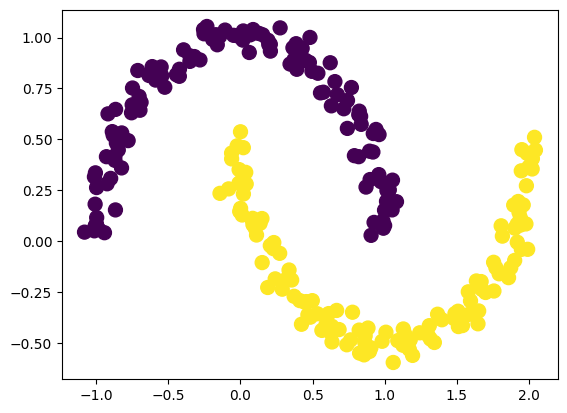

In [6]:
plt.scatter(X[:,0],X[:,1],c=y,s=100)
plt.show()

In [7]:

model = Sequential()

model.add(Dense(10, activation='sigmoid', input_dim=2))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(10, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [10]:
model.get_weights()

[array([[ 0.6122543 ,  0.0207966 , -0.19101995, -0.38553053,  0.01107264,
          0.0314461 ,  0.6451213 , -0.472979  ,  0.3430521 , -0.27481177],
        [-0.04135346,  0.26944226, -0.56127095,  0.2587604 , -0.40134218,
          0.24963897, -0.4709959 , -0.19622493, -0.6139268 , -0.5335767 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.31398708,  0.06883347, -0.51228684, -0.12579495,  0.5053909 ,
          0.24849421,  0.04873997, -0.13326609, -0.07196063,  0.14819264],
        [ 0.21311355,  0.01090401, -0.21085516, -0.37825823, -0.01481706,
         -0.02773046,  0.52656066,  0.38514745, -0.35054147,  0.5159296 ],
        [ 0.30386645, -0.23323077,  0.04737759, -0.36005592,  0.31559134,
         -0.49049103, -0.2121954 ,  0.27326423, -0.13994408, -0.36881506],
        [-0.06043369,  0.06606984, -0.2812606 , -0.23659977,  0.06079292,
          0.12270039, -0.24403998,  0.15974581,  0.5443145 ,  0.12882572],
        [ 0.09785

In [13]:
old_weights=model.get_weights()[0]

In [14]:
X_train, X_test, y_train ,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
model.fit(X_train,y_train,epochs=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5100 - loss: 0.6959


In [16]:
new_weights=model.get_weights()[0]

In [18]:
gradient=(old_weights-new_weights)/0.001
gradient

array([[ 0.08672475, -0.07337518, -0.02656877, -0.05298853,  0.13946275,
         0.1705475 ,  0.13446808,  0.03221631,  0.00670552, -0.14349818],
       [-0.07551536,  0.05146861,  0.01758337,  0.04222989, -0.09974837,
        -0.12558699, -0.12120604, -0.02518296, -0.00476837,  0.10424852]],
      dtype=float32)

In [21]:
prec_change=abs(100*(old_weights-new_weights)/old_weights)


In [23]:
print(prec_change)

[[1.4164826e-02 3.5282302e-01 1.3908898e-02 1.3744314e-02 1.2595264e+00
  5.4234874e-01 2.0843845e-02 6.8113618e-03 1.9546661e-03 5.2216899e-02]
 [1.8260951e-01 1.9101907e-02 3.1327775e-03 1.6320076e-02 2.4853697e-02
  5.0307445e-02 2.5733991e-02 1.2833722e-02 7.7670033e-04 1.9537682e-02]]
